# Pipeline Example

This hole processe exemplifies how the cmplete functionality is expected to run

## Sample a "Real" Dataset

The first fundamental step is to sample a unique dataset that will represent the real detaset received by the company for analisys. For thar, we set the "real" parameters to be used:

In [1]:
cost_failure = 1200
cost_component = 100
cost_inspection = 100
cost_replacement = 1000

In [2]:
eta = 30*24
beta = 3
expiration = 1.1*eta

In [3]:
mu = 7*24
sigma = 0.15*mu
theta = 12

In [4]:
inspection_threshold = 0.5
inspection_deviation = 0.05

In [5]:
r=0.0005
nu=0.00005

In [6]:
param = {
    # component failure age parameters
    "eta":eta,
    "beta":beta,
    "expiration":expiration,
    # inspection quality and schedule
    "mu":mu,
    "sigma":sigma,
    "theta":theta,
    "inspection_deviation":inspection_deviation,
    "inspection_threshold":inspection_threshold,
    # population dynamic parameters
    "r": r,
    "nu": nu
}

costs = {
    "replacement":cost_replacement,
    "inspection":cost_inspection,
    "component":cost_component,
    "failure":cost_failure
}

We sample a datset and export its `sample.csv` and `table.csv`. We also visuzalize its KPIs.

In [ ]:
from simmcm2d import sample_datasets, get_kpi

In [9]:
df = sample_datasets(param, costs,
                     n_systems = 250,
                     date_first = "2010-01-01",
                     date_final = "2025-12-31 12:00",
                     id_0_component=0, id_0_system=0,
                     # filepaths
                     output_data_filepath="sample.csv",
                     output_table_filepath="table.csv")

df.head()

,system_id,component_id,event_date,event_time,event_type,event_report,system_age,component_age,usage_since_last_event_h,FF,cost_event,cost_cumulated
0,1,1,2010-01-08,04:49:08,inspection,NaN,172.82,172.82,172.82,None,100,100
1,1,1,2010-01-13,16:01:08,failure,NaN,304.02,304.02,131.20,None,1200,1300
2,1,1,2010-01-13,16:01:08,replacement,unused,304.02,304.02,0.00,None,1100,2400
3,1,2,2010-01-19,05:52:17,inspection,NaN,437.87,133.85,133.85,None,100,2500
4,1,2,2010-01-24,15:22:16,inspection,NaN,567.37,263.35,129.50,None,100,2600


We use the sample to compute the sample's KPI as follows:

In [11]:
KPI = get_kpi(df, costs=costs)

KPI

{'Average of failure per month': np.float64(158.81),
 'Average of failure per trimestre': np.float64(473.95),
 'Average of failure per year': np.float64(1895.8),
 'Standard Deviation per month': np.float64(70.64),
 'Standard Deviation per trimestre': np.float64(210.68),
 'Standard Deviation per year': np.float64(839.07),
 'Average of replacement per month': np.float64(251.41),
 'Average of replacement per trimestre': np.float64(754.22),
 'Average of replacement per year': np.float64(3016.9),
 'Average of failure per system (total life)': np.float64(18.45),
 'Average of failure per system  / month': np.float64(1.22),
 'Average of failure per system / trimestre': np.float64(2.33),
 'Average of failure per system  / year': np.float64(6.73),
 'Average of replacement per system (total life)': np.float64(29.1),
 'Average of replacement per system / month': np.float64(1.258),
 'Average of replacement per system / trimestre': np.float64(3.44),
 'Average of replacement per system / year': np.fl

## Estimate Unknown Parametes

First, we estimate the parameters assumed to be unknown, and set the others fixed

In [12]:
from pipmcm2d import estimate_parameters

In [15]:
insp_param, comp_param = estimate_parameters(df)
mu_est, sigma_est = insp_param
eta_est, beta_est = comp_param

print("mu_est:", mu_est)
print("sigma_est:", sigma_est)
print("eta_est:", eta_est)
print("beta_est:", beta_est)

mu_est: 166.49524036744896
sigma_est: 26.641315462583382
eta_est: 718.7544544005904
beta_est: 3.016745635592456


## Optimize Inspection Policy

We will make use of the parameters (known and estimations) to compute a new policy: 

In [ ]:
import numpy as np
from pipmcm2d import compute_cost, algorithme_genetique

In [19]:
fixed_param = {
    "eta": eta_est,
    "beta": beta_est,
    "expiration": expiration,
    "r": r,
    "nu": nu
}

# Initital parameters
theta_init = np.array([
    mu_est,           
    sigma_est,
    theta,
    inspection_deviation,   
    inspection_threshold
])

bornes = [
    [150, 600],       # mu
    [20, 80],         # sigma
    [10, 40],         # theta
    [0.05, 0.90],     # deviation 
    [0.05, 0.95]      # threshold
]

### Use the Optimization Functionality

We run an Optimization Policy by making use of Known and Estimated parameters:

In [ ]:
from pipmcm2d import compute_cost, algorithme_genetique

In [ ]:
rng = np.random.default_rng(1234)

meilleur_theta, meilleur_cout, hist_best, hist_mean, hist_valid = algorithme_genetique(
    fixed_param=fixed_param, costs=costs, bornes=bornes, rng=rng,
    taille_pop=15, max_generation=30, M_test=3, M_validate=20)

génération |    Best_fast |    Mean_fast |   Best_valid
         1 |     62960.58 |     69864.27 |     68075.65
         2 |     63597.19 |     69468.68 |     66277.35
         3 |     62334.26 |     68821.90 |     68679.07
         4 |     59643.22 |     68264.82 |     62885.27
         5 |     63625.07 |     69399.47 |     63853.61
         6 |     63409.51 |     67252.69 |     65212.82
         7 |     62377.49 |     67036.33 |     65685.36
         8 |     61760.70 |     67207.47 |     63056.18
         9 |     57787.24 |     65788.11 |     64262.87
        10 |     61721.18 |     66699.07 |     63842.66
        11 |     59655.25 |     67523.38 |     69606.82
        12 |     58582.42 |     67416.03 |     64453.69
Arret anticipé: aucune amélioration (Validée) depuis 8 générations.


In [23]:
seeds_eval = rng.integers(0, 2**31 - 1, size=20, dtype=np.int64)

c_init = compute_cost(theta_init, fixed_param, costs, M=20, seeds=seeds_eval)
c_best = compute_cost(meilleur_theta, fixed_param, costs, M=20, seeds=seeds_eval)

print(f"{c_init} | {c_best}| {c_init - c_best}")

75059.30530000002 | 65113.494900000005| 9945.810400000017


In [28]:
print("meilleur_theta:", meilleur_theta)

meilleur_theta: [304.61280573  56.9992948   12.60649166   0.9          0.79191794]


In [29]:
print(f"Cost Improvement: {100*(c_init - c_best)/c_init}%")

Cost Improvement: 13.250602787020483%


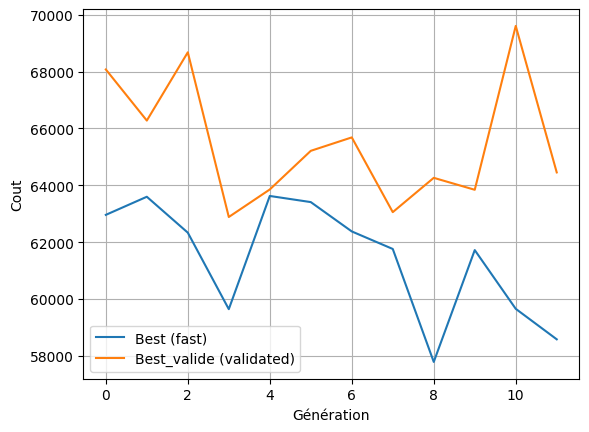

In [25]:
import matplotlib.pyplot as plt 

plt.figure()
plt.plot(hist_best, label = "Best (fast)")
plt.plot(hist_valid, label = "Best_valide (validated)")
plt.xlabel("Génération")
plt.ylabel("Cout")
plt.legend()
plt.grid(True)
plt.show()